In [1]:
import numpy as np
from matplotlib import pyplot as plt
from cycler import cycler
plt.rc('axes', prop_cycle=cycler(color=['0.0', '0.4', '0.8']))
import matplotlib; matplotlib.rcParams.update({'font.size': 18})

In [2]:
from pywrangling.jupyter_slides_functions import apply_beamer_theme
from pywrangling.graphing_functions import use_plotplainblind, set_top_ylabel
from IPython.display import HTML
import course_helpers as chh
import ml_helpers as mlh
apply_beamer_theme(
    "madrid",
    skip_font_download=True,
    author="Robert Pettis",
    date="Fall 2026",
    show_slide_number=True,
    cell_tags=True,
    notebook_path="10-Neural-Network-Fundamentals.ipynb",
)

<IPython.core.display.Javascript object>


✓ Cell tag CSS applied for 24 cell(s):
 cell_index   slide_id                                  tags
         10  slide-1-1 slide_hide_prompt, slide_remove_input
         12  slide-1-2 slide_hide_prompt, slide_remove_input
         14  slide-1-3 slide_hide_prompt, slide_remove_input
         16  slide-1-4 slide_hide_prompt, slide_remove_input
         19  slide-1-6 slide_hide_prompt, slide_remove_input
         23  slide-2-1 slide_hide_prompt, slide_remove_input
         25  slide-2-2 slide_hide_prompt, slide_remove_input
         27  slide-2-3 slide_hide_prompt, slide_remove_input
         29  slide-2-4 slide_hide_prompt, slide_remove_input
         31  slide-2-5 slide_hide_prompt, slide_remove_input
         33  slide-2-6 slide_hide_prompt, slide_remove_input
         36  slide-2-8 slide_hide_prompt, slide_remove_input
         38  slide-2-9 slide_hide_prompt, slide_remove_input
         40 slide-2-10 slide_hide_prompt, slide_remove_input
         42 slide-2-11 slide_hide_prompt, sli

In [3]:
# Presenter clicker remap. Guarded so a student's Restart & Run All
# never breaks on it if pywrangling is missing.
try:
    from pywrangling.jupyter_slides_functions import enable_reveal_key_remap
    enable_reveal_key_remap({
        38: "left",         # Up arrow   -> previous  (clicker left button)
        40: "right",        # Down arrow -> next      (clicker right button)
        27: "up",           # Escape     -> up        (clicker play button)
        66: "down",         # B          -> down      (clicker stop button)
        116: None,          # F5         -> block refresh
        9:  "togglePause",  # Tab        -> black screen
    })
except Exception:
    pass  # not presenting, or pywrangling not installed

In [4]:
# One place that knows how to draw his diagram. Every slide in the walk through
# is the same picture with different numbers alive on it, which is how he does
# it: the dose sits in the input box, a red x marks where we are on the
# activation function, and the dot lands on the effectiveness graph.
import numpy as np
import matplotlib.pyplot as plt
import course_helpers as chh
import ml_helpers as mlh

NW = mlh._NW                       # the same network lecture 11 optimises
W1, B1, O1 = NW["w1"], NW["b1"], NW["o1"]
W2, B2, O2 = NW["w2"], NW["b2"], NW["o2"]
DOSE, EFF = mlh._DOSE, mlh._EFF
BLUE, ORANGE, GREEN = chh.MADRID, chh.ACCENT, "#2E8B57"
FADE = "#CBCEDA"
STAGES = ["in", "pre", "act", "out", "sum"]
GRID_D = np.round(np.arange(0.0, 1.001, 0.1), 2)


def relu(x):
    return np.maximum(x, 0.0)


def top_pre(d):
    return W1 * np.asarray(d, float) + B1


def bot_pre(d):
    return W2 * np.asarray(d, float) + B2


def top_out(d):
    return O1 * relu(top_pre(d))


def bot_out(d):
    return O2 * relu(bot_pre(d))


def net(d):
    return top_out(d) + bot_out(d)


def _txt(ax, x, y, s, col, fs=9.5, weight="normal"):
    ax.text(x, y, s, ha="center", va="center", fontsize=fs, color=col,
            zorder=8, weight=weight,
            bbox=dict(boxstyle="round,pad=0.16", facecolor="white",
                      edgecolor="none"))


def net_panel(ax, dose=None, path=None, upto="in"):
    """His diagram. path says which half of the network is awake, upto says how
       far along it we have got. Everything else is greyed out, the way he fades
       the parts he is not talking about."""
    ax.set_facecolor("white")
    ax.axis("off")
    ax.set_xlim(0, 11.4)
    ax.set_ylim(0.15, 5.9)
    s = STAGES.index(upto)

    def col(which, need, base):
        awake = path in (which, "both") and s >= STAGES.index(need)
        return base if awake else FADE

    def box(x, y, label, c, w=1.75, h=1.05, fs=10.5, weight="normal"):
        ax.add_patch(plt.Rectangle((x - w / 2, y - h / 2), w, h, zorder=4,
                                   facecolor="white", edgecolor=c, lw=2.2))
        ax.text(x, y, label, ha="center", va="center", fontsize=fs, zorder=5,
                color=chh.INK if c != FADE else FADE, weight=weight)

    def act_box(x, y, c, z=None, w=1.4, h=1.1):
        ax.add_patch(plt.Rectangle((x - w / 2, y - h / 2), w, h, zorder=4,
                                   facecolor="white", edgecolor=c, lw=2.4))
        t = np.linspace(-1.3, 1.3, 80)
        ax.plot(x + t * (w * 0.33), y - h * 0.30 + relu(t) * (h * 0.42),
                color=c, lw=2.0, zorder=5)
        if z is not None:
            zz = float(np.clip(z, -1.3, 1.3))
            ax.plot([x + zz * (w * 0.33)],
                    [y - h * 0.30 + relu(zz) * (h * 0.42)], marker="x", ms=13,
                    mew=3.2, color=chh.FITLINE, zorder=7)

    def arrow(p0, p1, c, lw=1.8):
        ax.annotate("", xy=p1, xytext=p0, zorder=3,
                    arrowprops=dict(arrowstyle="-|>", lw=lw, color=c))

    def at(p0, p1, f):
        return (p0[0] + f * (p1[0] - p0[0]), p0[1] + f * (p1[1] - p0[1]))

    box(1.2, 3.0, "%g" % dose if dose is not None else "Dose\n(input)",
        chh.INK, fs=16 if dose is not None else 10.5,
        weight="bold" if dose is not None else "normal")
    if dose is not None:
        ax.text(1.2, 3.92, "Dose (input)", ha="center", fontsize=9.5,
                color=chh.INK)

    tp, bp = (2.1, 3.3), (2.1, 2.7)
    ta, ba = (4.38, 4.44), (4.38, 1.56)
    ct = col("top", "pre", BLUE)
    cb = col("bottom", "pre", ORANGE)
    arrow(tp, ta, ct)
    arrow(bp, ba, cb)
    _txt(ax, *at(tp, ta, 0.28), "x %g" % W1, ct)
    _txt(ax, *at(tp, ta, 0.66), "+ (%g)" % B1, ct)
    _txt(ax, *at(bp, ba, 0.28), "x %g" % W2, cb)
    _txt(ax, *at(bp, ba, 0.66), "+ (%g)" % B2, cb)

    zt = float(top_pre(dose)) if (dose is not None and
                                  path in ("top", "both") and
                                  s >= STAGES.index("act")) else None
    zb = float(bot_pre(dose)) if (dose is not None and
                                  path in ("bottom", "both") and
                                  s >= STAGES.index("act")) else None
    act_box(5.2, 4.5, col("top", "act", BLUE), zt)
    act_box(5.2, 1.5, col("bottom", "act", ORANGE), zb)

    to, bo = (5.95, 4.5), (5.95, 1.5)
    sm = (8.35, 3.0)
    cto = col("top", "out", BLUE)
    cbo = col("bottom", "out", ORANGE)
    arrow(to, (7.75, 3.25), cto)
    arrow(bo, (7.75, 2.75), cbo)
    _txt(ax, *at(to, (7.75, 3.25), 0.45), "x (%g)" % O1, cto)
    _txt(ax, *at(bo, (7.75, 2.75), 0.45), "x %g" % O2, cbo)

    csum = chh.INK if s >= STAGES.index("sum") else FADE
    ax.text(sm[0], sm[1], "Sum", ha="center", va="center", fontsize=11,
            style="italic", color=csum, zorder=5)
    arrow((8.85, 3.0), (9.25, 3.0), csum, lw=2.0)
    box(10.15, 3.0, "Effectiveness\n(output)", GREEN if s >= STAGES.index("sum")
        else FADE, w=2.1, fs=9.5)


def eff_panel(ax, dots=None, colour=BLUE, line=None, ylim=(-0.4, 1.4),
              ylab="Effectiveness", data=False, mark=None, title=None):
    """The graph the dots land on. Same axes as the data all the way through,
       which is the point of drawing it this way."""
    ax.set_facecolor("white")
    ax.grid(True, color=chh.GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.axhline(0, color="#7A7A85", lw=1.0, zorder=1)
    if data:
        ax.scatter(DOSE, EFF, s=120, facecolors="none", edgecolors=chh.INK,
                   lw=1.6, zorder=6)
    if line is not None:
        g = np.linspace(0, 1, 300)
        ax.plot(g, line(g), color=colour, lw=3.0, zorder=4)
    if dots is not None and len(dots):
        d = np.asarray(dots, float)
        ax.scatter(d[:, 0], d[:, 1], s=105, color=colour, edgecolors=chh.INK,
                   lw=1.2, zorder=5)
    if mark is not None:
        ax.scatter([mark[0]], [mark[1]], s=230, marker="X", color=chh.FITLINE,
                   edgecolors=chh.INK, lw=1.2, zorder=7)
    ax.set_xlim(-0.04, 1.04)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Drug dose", fontsize=11)
    ax.text(0, 1.02, ylab, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=11, color=chh.INK)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    if title:
        ax.set_title(title, fontsize=12, color=colour, weight="bold", pad=26)


def step(dose=None, path=None, upto="in", dots=None, colour=BLUE, line=None,
         ylim=(-0.4, 1.4), ylab="Effectiveness", data=False, mark=None,
         title=None, ratio=(1.35, 1.0)):
    """One slide of the walk through: his diagram on the left, the graph the
       dots are landing on at the right."""
    fig, (a, b) = plt.subplots(1, 2, figsize=(13.2, 4.3), dpi=110,
                               gridspec_kw=dict(width_ratios=list(ratio)))
    fig.patch.set_facecolor("white")
    net_panel(a, dose=dose, path=path, upto=upto)
    eff_panel(b, dots=dots, colour=colour, line=line, ylim=ylim, ylab=ylab,
              data=data, mark=mark, title=title)
    fig.tight_layout()
    plt.close(fig)
    return fig


def dots_upto(d_max, fn):
    d = GRID_D[GRID_D <= d_max + 1e-9]
    return np.column_stack([d, fn(d)])

# Neural Networks: Fundamentals

### Bending straight lines into a shape that fits

Causal Machine Learning

## Before We Start: Updating Your Repo

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Reminder</span> &nbsp;same git rhythm as the setup lecture.

| command | what it does |
|---|---|
| `git pull upstream main` | grab today's lecture before class |
| `git checkout -b ps1` | a branch for your own work |
| `git add .` then `git commit -m "..."` | snapshot your changes |
| `git push origin ps1` | send it to your fork, then open a pull request |
| `git status` | what changed, any time |

### Last Time: Ensembles of Trees

- <b style="color:#73000A;">Bagging</b> fits many trees to bootstrapped samples and averages them
- <b style="color:#73000A;">Random forests</b> go further and sample variables at each split, so the trees disagree more
- <b style="color:#73000A;">Boosting</b> goes the other way: trees in sequence, each fitting what is left over
- Both are ways to bend a prediction. Today bends it with <b style="color:#73000A;">arithmetic</b> instead


### Where We Are Going

- A neural network takes data in and transforms it into a prediction
- The parts: <b style="color:#73000A;">nodes</b>, <b style="color:#73000A;">weights</b>, <b style="color:#73000A;">biases</b>, <b style="color:#73000A;">activation functions</b>
- Those parts bend straight lines into a <b style="color:#73000A;">curve that fits</b>
- We trace one small network by hand, input to output
- Then build the identical network in <b style="color:#73000A;">PyTorch</b>

## The Problem: A Straight Line Will Not Do

- Data: a drug given at <b style="color:#73000A;">low</b>, <b style="color:#73000A;">medium</b>, and <b style="color:#73000A;">high</b> dose
- The medium dose works. Low and high do not
- Effectiveness is $0$, $1$, $0$ across the three doses
- No straight line passes near all three points
- We need a model that can <b style="color:#73000A;">bend</b>

### Different Data Needs Different Shapes

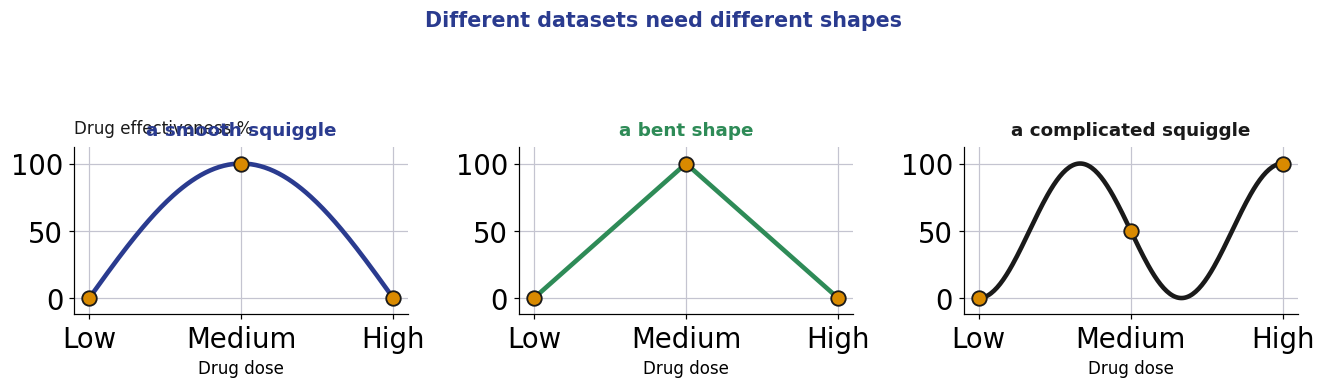

In [5]:
mlh.fig_squiggle_examples()

### The Data

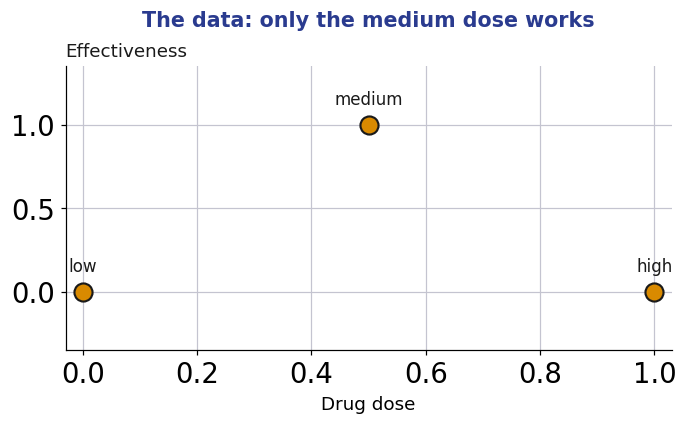

In [6]:
mlh.fig_nn_data()

### A Straight Line Cannot Do It

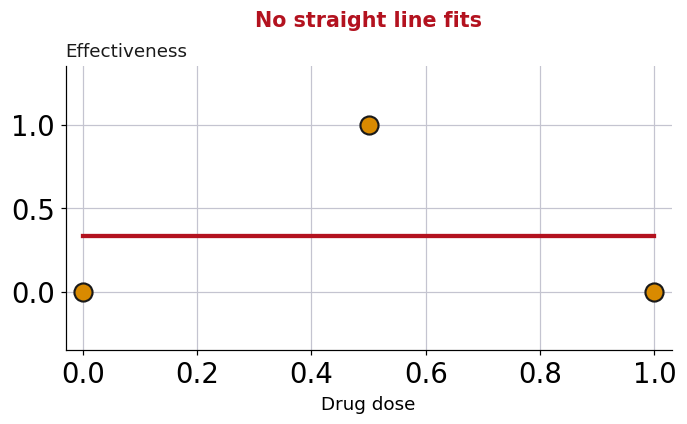

In [7]:
mlh.fig_nn_straight_line()

## Anatomy of a Neural Network

- <b style="color:#73000A;">Nodes</b>: the boxes
- <b style="color:#73000A;">Weights</b>: the numbers we <b style="color:#73000A;">multiply</b> along a connection
- <b style="color:#73000A;">Biases</b>: the numbers we <b style="color:#73000A;">add</b>
- <b style="color:#73000A;">Activation function</b>: the bend inside a node. Here, <b style="color:#73000A;">ReLU</b>
- Weights and biases are estimated by <b style="color:#73000A;">backpropagation</b>, which is next lecture

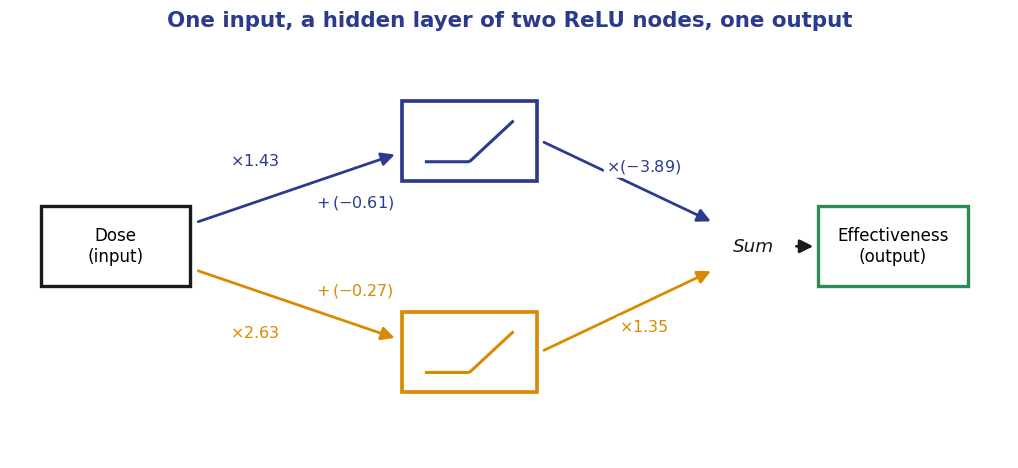

In [8]:
mlh.fig_nn_architecture()

### Layers

- <b style="color:#73000A;">Input layer</b>: the nodes where data enters
- <b style="color:#73000A;">Hidden layers</b>: everything between input and output
- <b style="color:#73000A;">Output layer</b>: the prediction comes out here
- This example: 1 input node, 1 hidden layer of 2 nodes, 1 output node
- More layers and more nodes means a more complicated shape can be fit

### Three Common Activation Functions

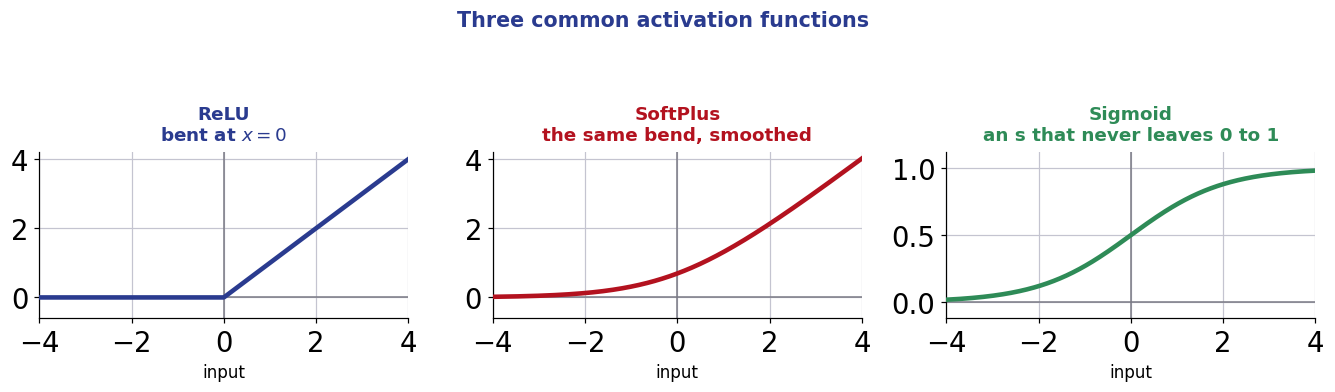

In [9]:
x = np.linspace(-4, 4, 400)

# ReLU and SoftPlus share a scale so the smoothing is visible. The sigmoid gets
# its own, because on a scale that runs to 4 an s that lives inside 0 to 1 looks
# like a step.
PANELS = [("ReLU", np.maximum(x, 0), chh.MADRID,
           "bent at $x=0$", (-0.6, 4.2), None),
          ("SoftPlus", np.log1p(np.exp(x)), chh.FITLINE,
           "the same bend, smoothed", (-0.6, 4.2), None),
          ("Sigmoid", 1 / (1 + np.exp(-x)), GREEN,
           "an s that never leaves 0 to 1", (-0.12, 1.12), [0, 0.5, 1])]

fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.5), dpi=110)
fig.patch.set_facecolor("white")
for ax, (name, y, col, sub, ylim, yticks) in zip(axes, PANELS):
    ax.set_facecolor("white")
    ax.grid(True, color=chh.GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.axhline(0, color="#7A7A85", lw=1)
    ax.axvline(0, color="#7A7A85", lw=1)
    ax.plot(x, y, color=col, lw=3.0, zorder=3)
    ax.set_xlim(-4, 4)
    ax.set_ylim(*ylim)
    if yticks is not None:
        ax.set_yticks(yticks)
    ax.set_xlabel("input", fontsize=11)
    ax.set_title("%s\n%s" % (name, sub), fontsize=12, color=col,
                 weight="bold", pad=8)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.suptitle("Three common activation functions", fontsize=13.5,
             color=chh.MADRID, weight="bold", y=1.04)
fig.tight_layout()

### The Three, as Formulas

- $\text{ReLU}(x) = \max(0, x)$
- $\text{SoftPlus}(x) = \log\!\left(1 + e^{x}\right)$
- $\sigma(x) = \dfrac{1}{1 + e^{-x}}$

- A connection to keep: SoftPlus's <b style="color:#73000A;">derivative is</b> $\sigma(x)$, and ReLU's is a 0/1 gate. Derivatives of activations are what backpropagation will chain together

## A Neural Network in Action, One Step at a Time

Both axes are scaled to run from <b style="color:#73000A;">0</b> to <b style="color:#73000A;">1</b>, so a low dose is 0 and a high
dose is 1. Then we plug doses in, one at a time, and watch what comes out.

### Plug In the Lowest Dose

$$(\text{dose} \times 1.43) + (-0.61) \;=\; (0 \times 1.43) + (-0.61) \;=\; -0.61$$

That is an <b style="color:#73000A;">x axis coordinate</b> for the activation function in the top node.
Nothing else. It is not a prediction of anything yet.

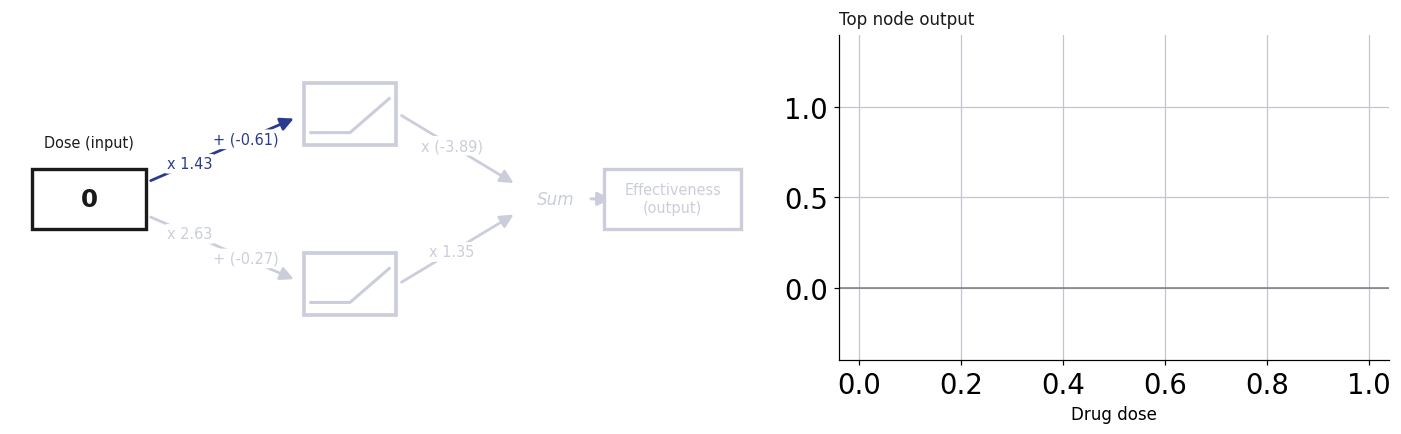

In [10]:
display(step(dose=0.0, path="top", upto="pre", colour=BLUE,
             ylab="Top node output", ylim=(-0.4, 1.4)))

### Through the Activation Function

$$\text{ReLU}(-0.61) \;=\; \max(0,\, -0.61) \;=\; 0$$

So when the dose is 0, the top node puts out <b style="color:#73000A;">0</b>. That is the first blue dot.

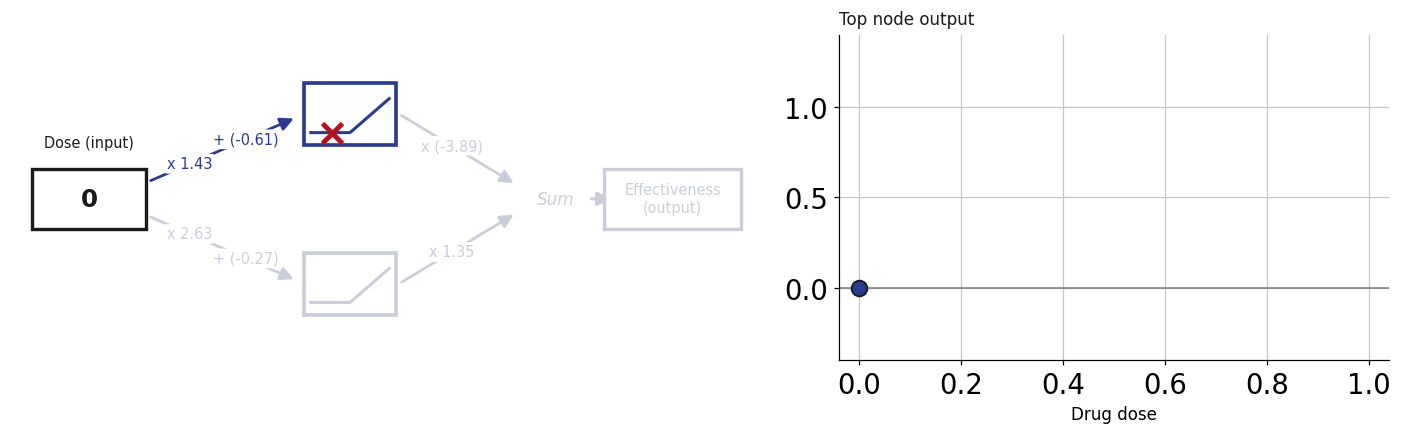

In [11]:
display(step(dose=0.0, path="top", upto="act",
             dots=dots_upto(0.0, lambda d: relu(top_pre(d))), colour=BLUE,
             ylab="Top node output", ylim=(-0.4, 1.4)))

### Turn the Dose Up to 0.2

$$(0.2 \times 1.43) + (-0.61) = -0.32 \qquad\Longrightarrow\qquad \text{ReLU}(-0.32) = 0$$

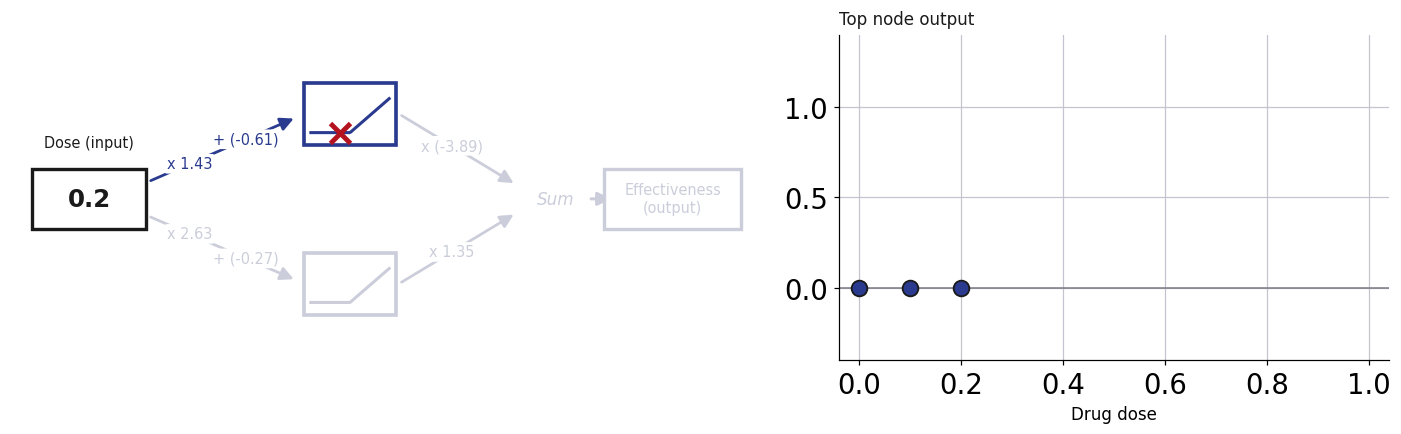

In [12]:
display(step(dose=0.2, path="top", upto="act",
             dots=dots_upto(0.2, lambda d: relu(top_pre(d))), colour=BLUE,
             ylab="Top node output", ylim=(-0.4, 1.4)))

### And 0.4

$$(0.4 \times 1.43) + (-0.61) = -0.04 \qquad\Longrightarrow\qquad \text{ReLU}(-0.04) = 0$$

Still flat...

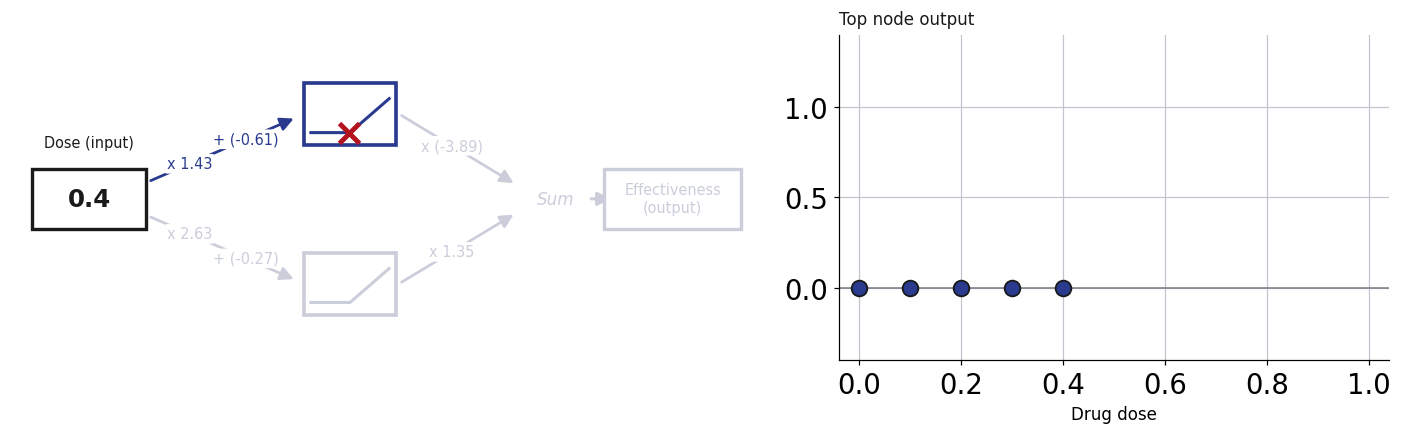

In [13]:
display(step(dose=0.4, path="top", upto="act",
             dots=dots_upto(0.4, lambda d: relu(top_pre(d))), colour=BLUE,
             ylab="Top node output", ylim=(-0.4, 1.4)))

### Keep Going All the Way to 1

Every dose from 0 to 1, through the weight, through the bias, through ReLU.
The dots line up into a <b style="color:#73000A;">bent line</b>.

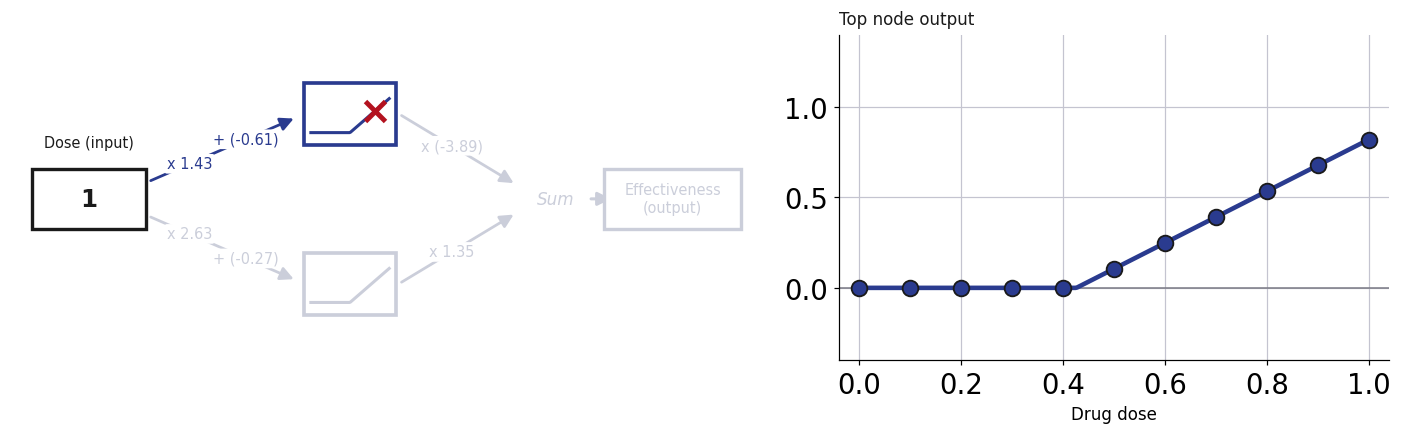

In [14]:
display(step(dose=1.0, path="top", upto="act",
             dots=dots_upto(1.0, lambda d: relu(top_pre(d))), colour=BLUE,
             line=lambda d: relu(top_pre(d)), ylab="Top node output",
             ylim=(-0.4, 1.4)))

### Multiply by the Output Weight

The last number on the top path is $\times(-3.89)$. It is negative, so the bent
line <b style="color:#73000A;">flips over</b>, and it is bigger than one, so the bent line
<b style="color:#73000A;">stretches</b>.

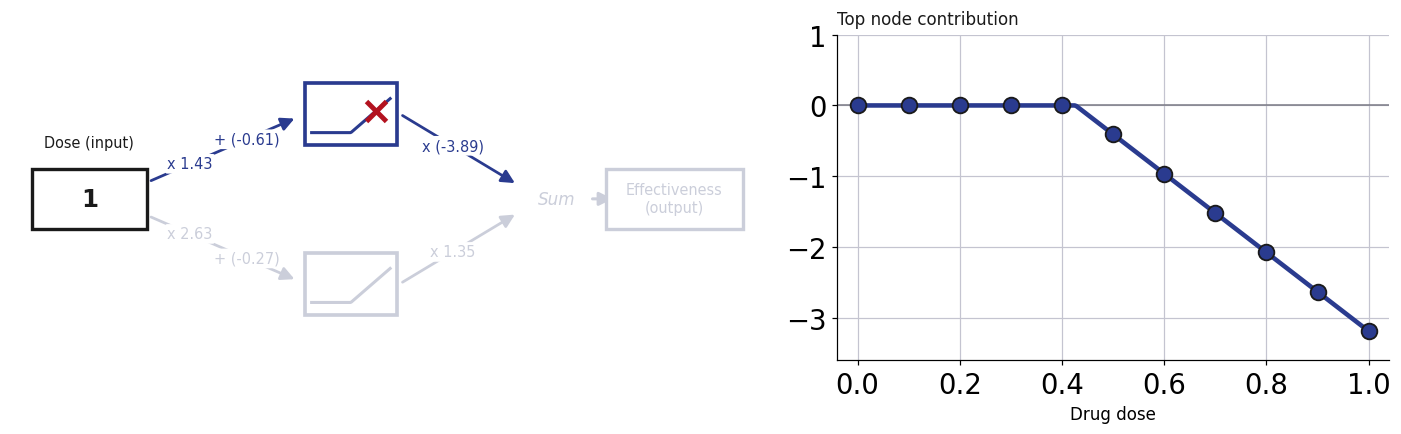

In [15]:
display(step(dose=1.0, path="top", upto="out",
             dots=dots_upto(1.0, top_out), colour=BLUE, line=top_out,
             ylab="Top node contribution", ylim=(-3.6, 1.0)))

### What We Just Did...

1. Plugged doses from 0 to 1 into the input
2. Turned each one into an x axis coordinate: $\times 1.43$, then $+(-0.61)$
3. Ran that through <b style="color:#73000A;">ReLU</b> to get a y axis coordinate
4. Scaled every y axis coordinate by $\times(-3.89)$

That is the whole top half of the network. The bottom half is the same four
moves with its own numbers.

### The Bottom Node, Same Four Moves

$$(\text{dose} \times 2.63) + (-0.27) \qquad\Longrightarrow\qquad \text{ReLU} \qquad\Longrightarrow\qquad \times 1.35$$

A different weight and a different bias...

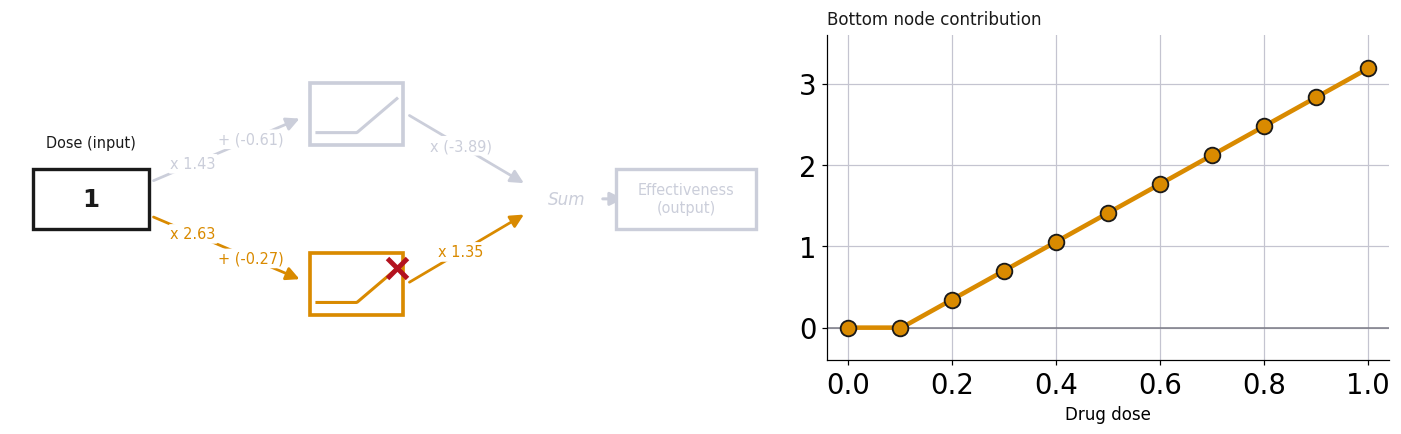

In [16]:
display(step(dose=1.0, path="bottom", upto="out",
             dots=dots_upto(1.0, bot_out), colour=ORANGE, line=bot_out,
             ylab="Bottom node contribution", ylim=(-0.4, 3.6)))

### Two Bent Lines...
One hangs down, one climbs up, and neither goes near the data.

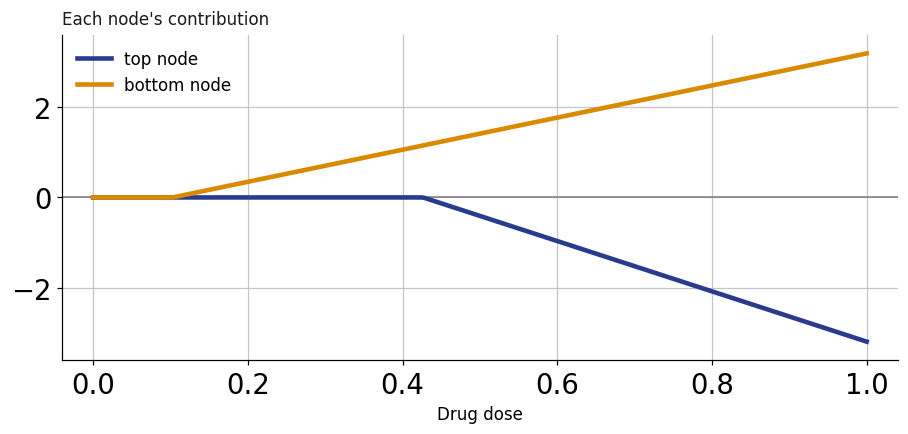

In [17]:
g = np.linspace(0, 1, 300)
fig, ax = plt.subplots(figsize=(8.6, 4.3), dpi=110)
fig.patch.set_facecolor("white")
eff_panel(ax, ylim=(-3.6, 3.6), ylab="Each node's contribution")
ax.plot(g, top_out(g), color=BLUE, lw=3.0, zorder=4, label="top node")
ax.plot(g, bot_out(g), color=ORANGE, lw=3.0, zorder=4, label="bottom node")
ax.legend(frameon=False, fontsize=11, loc="upper left")
fig.tight_layout()

### Add Them Together


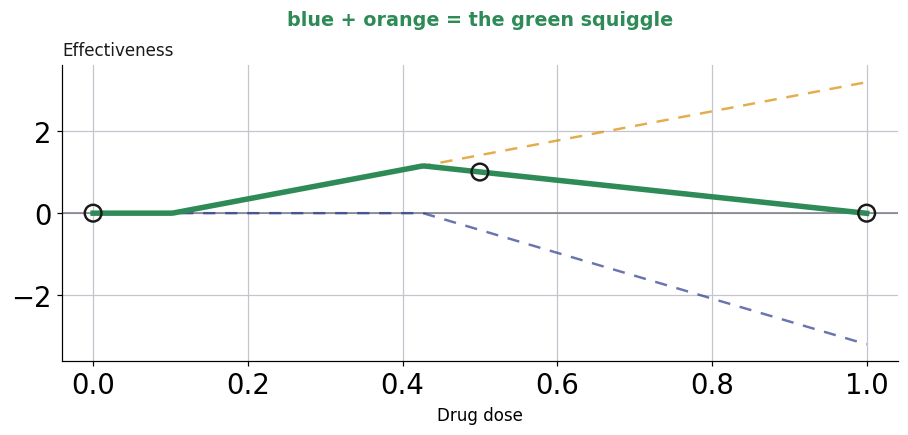

In [18]:
g = np.linspace(0, 1, 300)
fig, ax = plt.subplots(figsize=(8.6, 4.3), dpi=110)
fig.patch.set_facecolor("white")
eff_panel(ax, ylim=(-3.6, 3.6), ylab="Effectiveness", data=True)
ax.plot(g, top_out(g), color=BLUE, lw=1.6, ls=(0, (5, 4)), alpha=0.7, zorder=3)
ax.plot(g, bot_out(g), color=ORANGE, lw=1.6, ls=(0, (5, 4)), alpha=0.7, zorder=3)
ax.plot(g, net(g), color=GREEN, lw=3.6, zorder=5)
ax.set_title("blue + orange = the green squiggle", fontsize=12.5, color=GREEN,
             weight="bold", pad=26)
fig.tight_layout()

### Use It: Somebody Turns Up on 0.5

Run 0.5 through both halves and add:

- top: $\text{ReLU}(0.5 \times 1.43 - 0.61) \times (-3.89) = \text{ReLU}(0.105)\times(-3.89) = -0.41$
- bottom: $\text{ReLU}(0.5 \times 2.63 - 0.27) \times 1.35 = \text{ReLU}(1.045)\times 1.35 = 1.41$
- sum: $-0.41 + 1.41 = 1.00$

Closer to 1 than to 0, so we call that dose <b style="color:#73000A;">effective</b>.

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Terminology</span> &nbsp;running a fitted network forward to get a prediction is called
<b style="color:#73000A;">inference</b>. Econometrics uses that word for standard errors and
hypothesis tests, so check which of the two a paper means.

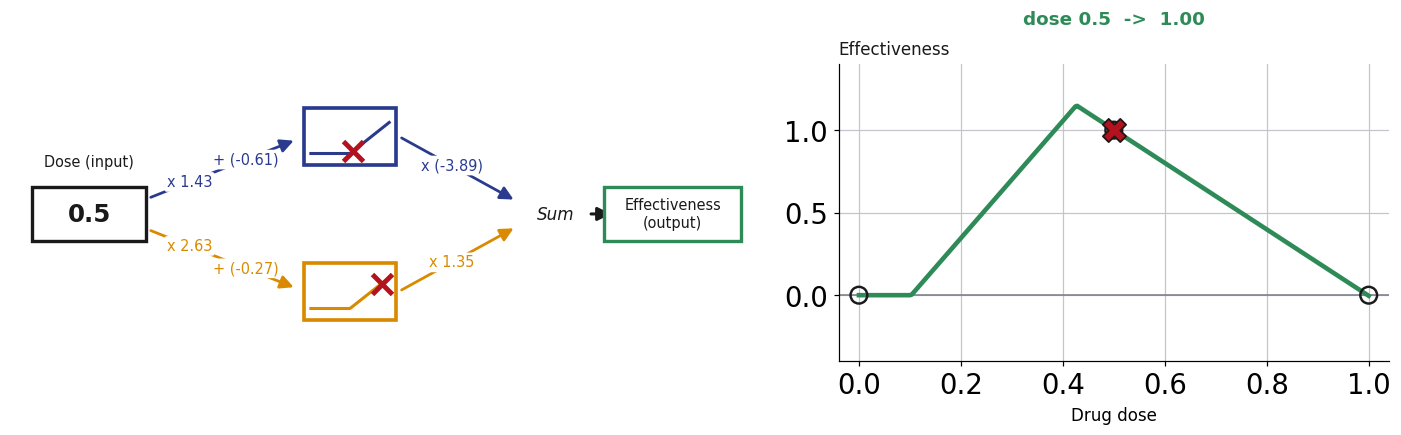

In [19]:
d = 0.5
display(step(dose=d, path="both", upto="sum",
             colour=GREEN, line=net, data=True, mark=(d, float(net(d))),
             ylim=(-0.4, 1.4), ylab="Effectiveness",
             title="dose %.1f  ->  %.2f" % (d, float(net(d)))))

### Why Is It Called a Neural Network?

- In the 1940s and 50s people thought the nodes were a bit like neurons and the connections a bit like synapses, and the name stuck
- The early ones were called <b style="color:#73000A;">perceptrons</b>, and they were built to recognise letters
- It is a machine that <b style="color:#73000A;">bends and adds curves until they fit</b>

### Watch It Sweep

Doses from 0 to 1, with both nodes and the running sum.

In [20]:
import re

# to_html5_video sizes the element from the figure, which comes out at 1680 wide
# and runs off the slide. Scale it down, keeping the aspect ratio.
video = mlh.nn_squiggle_animation().to_html5_video()
size = re.search(r'width="(\d+)"\s+height="(\d+)"', video)
w, h = int(size.group(1)), int(size.group(2))
WANT = 780
HTML(video.replace(size.group(0),
                   'width="%d" height="%d"' % (WANT, round(h * WANT / w))))

### Networks as Nested Functions

A network with one hidden layer is a composition of simpler functions:

$\hat{y} = w_o \sigma(w_h x + b_h) + b_o$

Or writing it step by step (this is what the computer evaluates):

$z = w_h x + b_h$ (preactivation)

$a = \sigma(z)$ (hidden-layer output)

$\hat{y} = w_o a + b_o$ (final prediction)

### Why Networks Are Expensive: Parameter Counting

A network takes parameters to store, and each one is optimized during training.

In [21]:
import numpy as np

# Example: classify images (28x28 pixels) into 10 classes
input_size = 28 * 28  # 784 pixels
hidden_sizes = [128, 64]
output_size = 10

# Layer 1: 784 inputs to 128 hidden nodes
params_1 = input_size * hidden_sizes[0] + hidden_sizes[0]  # weights + biases
print(f'Layer 1: {input_size} x {hidden_sizes[0]} = {input_size * hidden_sizes[0]} weights + {hidden_sizes[0]} biases = {params_1}')

# Layer 2: 128 hidden to 64 hidden
params_2 = hidden_sizes[0] * hidden_sizes[1] + hidden_sizes[1]
print(f'Layer 2: {hidden_sizes[0]} x {hidden_sizes[1]} = {hidden_sizes[0] * hidden_sizes[1]} weights + {hidden_sizes[1]} biases = {params_2}')

# Output layer: 64 hidden to 10 classes
params_out = hidden_sizes[1] * output_size + output_size
print(f'Output:  {hidden_sizes[1]} x {output_size} = {hidden_sizes[1] * output_size} weights + {output_size} biases = {params_out}')

total = params_1 + params_2 + params_out
print(f'\nTotal: {total} parameters (each needs one gradient, one optimizer state)')

# Compare: doubling width
wide_hidden = [256, 128]
wide_total = (input_size * wide_hidden[0] + wide_hidden[0] + 
              wide_hidden[0] * wide_hidden[1] + wide_hidden[1] +
              wide_hidden[1] * output_size + output_size)
print(f'\nIf we double hidden sizes: {wide_total} parameters (was {total})')
print(f'Width costs scale as O(input_width * hidden_width)')

Layer 1: 784 x 128 = 100352 weights + 128 biases = 100480
Layer 2: 128 x 64 = 8192 weights + 64 biases = 8256
Output:  64 x 10 = 640 weights + 10 biases = 650

Total: 109386 parameters (each needs one gradient, one optimizer state)

If we double hidden sizes: 235146 parameters (was 109386)
Width costs scale as O(input_width * hidden_width)


## Bigger Networks, the Same Four Moves

Everything so far used one input, one hidden layer of two nodes, and one
output. Real networks are wider in all three directions, and none of the
arithmetic changes.

### Add a Hidden Layer

The same picture with a second row of bent lines. Every node in the first
hidden layer feeds every node in the second, so the bends of layer one become
the <b style="color:#73000A;">inputs</b> to the bends of layer two.

Six numbers becomes <b style="color:#73000A;">twelve</b>.

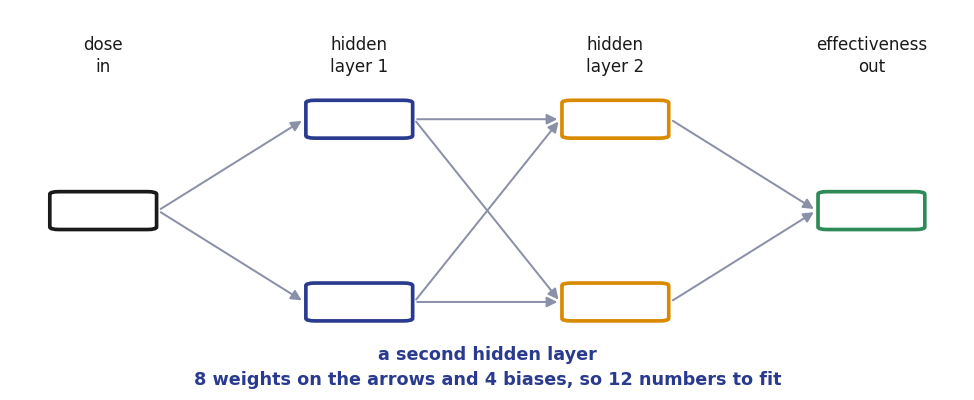

In [22]:
from matplotlib.patches import FancyBboxPatch

BW, BH = 0.115, 0.15          # node box, in axis coordinates


def draw_net(sizes, labels, caption, figsize=(9.2, 4.0)):
    """sizes is [inputs, hidden..., outputs], fully connected. Counts the
       weights on the arrows and one bias per hidden node, which is the
       convention our own network uses."""
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.axis("off")
    ax.set_xlim(-0.12, 1.12)
    ax.set_ylim(-0.82, 0.92)

    xs = np.linspace(0.0, 1.0, len(sizes))
    pos = [[(xs[j], y) for y in (np.linspace(0.42, -0.42, n) if n > 1
                                 else np.array([0.0]))]
           for j, n in enumerate(sizes)]

    for j in range(len(sizes) - 1):
        for x0, y0 in pos[j]:
            for x1, y1 in pos[j + 1]:
                ax.annotate("", xy=(x1 - BW / 2 - 0.014, y1),
                            xytext=(x0 + BW / 2 + 0.014, y0),
                            arrowprops=dict(arrowstyle="-|>", color="#8A90A8",
                                            lw=1.3, mutation_scale=14),
                            zorder=2)

    for j, col in enumerate(pos):
        if j == 0:
            edge, fill = chh.INK, "white"
        elif j == len(pos) - 1:
            edge, fill = GREEN, "white"
        else:
            edge, fill = (BLUE if j % 2 else ORANGE), "white"
        for x, y in col:
            ax.add_patch(FancyBboxPatch((x - BW / 2, y - BH / 2), BW, BH,
                                        boxstyle="round,pad=0.012", zorder=4,
                                        facecolor=fill, edgecolor=edge, lw=2.4))

    for x, lab in zip(xs, labels):
        ax.text(x, 0.62, lab, ha="center", va="bottom", fontsize=11,
                color=chh.INK, linespacing=1.3)

    weights = sum(a * b for a, b in zip(sizes, sizes[1:]))
    biases = sum(sizes[1:-1])
    ax.text(0.5, -0.72, "%s\n%d weights on the arrows and %d biases, so %d numbers to fit"
            % (caption, weights, biases, weights + biases),
            ha="center", va="center", fontsize=11.5, color=chh.MADRID,
            weight="bold", linespacing=1.5)
    fig.tight_layout()
    plt.close(fig)          # display() shows it; stop the backend showing it again
    return fig


display(draw_net([1, 2, 2, 1],
                 ["dose\nin", "hidden\nlayer 1", "hidden\nlayer 2", "effectiveness\nout"],
                 "a second hidden layer"))

### Add an Input

Two measurements rather than one. Say dose and <b style="color:#73000A;">age</b>. Every input reaches
every hidden node, so each node now bends a weighted sum of both.

Six numbers becomes <b style="color:#73000A;">eight</b>.

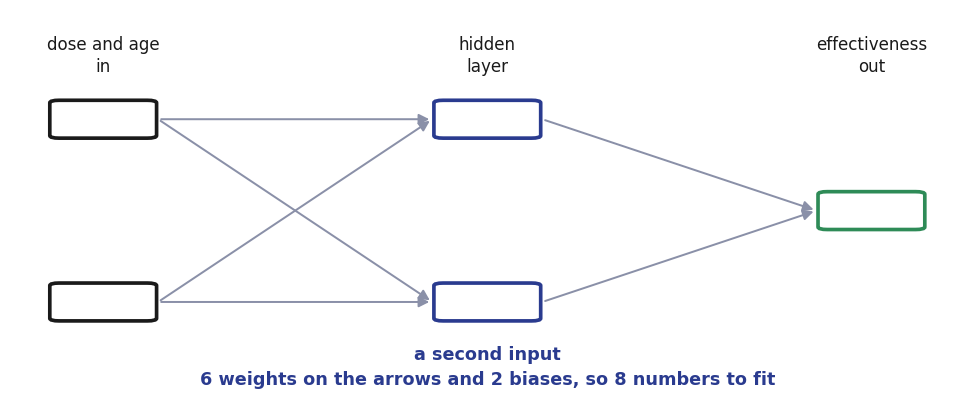

In [23]:
display(draw_net([2, 2, 1],
                 ["dose and age\nin", "hidden\nlayer", "effectiveness\nout"],
                 "a second input"))

### Where Two Arrows Meet

Dose <b style="color:#73000A;">0.5</b> and age <b style="color:#73000A;">0.4</b>, both scaled 0 to 1. Two arrows now land on the
top node, so multiply each input by <b style="color:#73000A;">its own</b> weight, add both, and then add
the bias once:

$$(0.5 \times 1.43) \;+\; (0.4 \times 0.80) \;+\; (-0.61)
\;=\; 0.715 + 0.32 - 0.61 \;=\; \mathbf{0.425}$$

$$\text{ReLU}(0.425) = 0.425$$

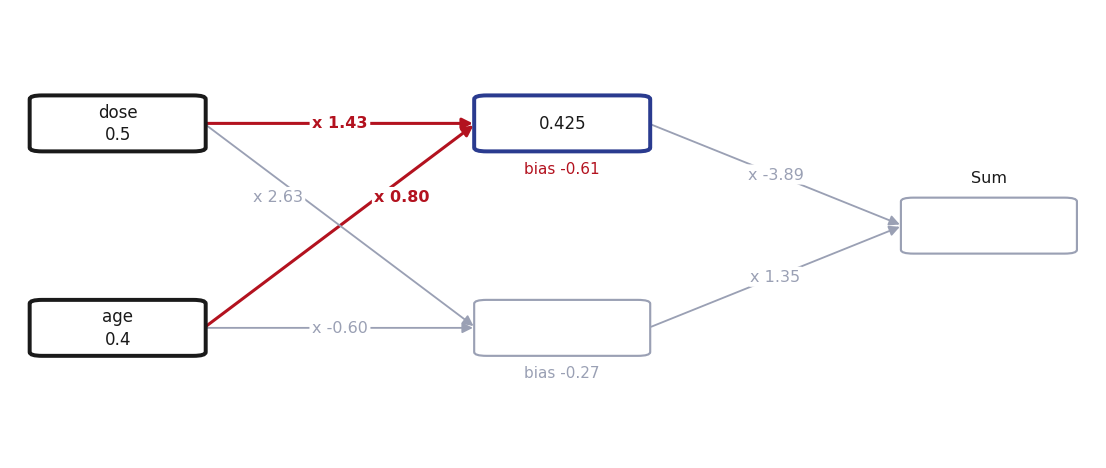

In [24]:
from matplotlib.patches import FancyBboxPatch

# One more weight per input per node. Everything else is the network we traced
# by hand, so at age 0 it still answers 1.00 for a dose of 0.5.
W1D, W1A, B1, O1 = 1.43, 0.80, -0.61, -3.89
W2D, W2A, B2, O2 = 2.63, -0.60, -0.27, 1.35
BW2, BH2 = 0.17, 0.18


def two_in(dose=None, age=None, upto="weights", figsize=(10.4, 4.6)):
    """upto: weights, top, both, out. Whatever is not yet computed stays grey."""
    z1 = h1 = z2 = h2 = y = None
    if dose is not None:
        z1 = dose * W1D + age * W1A + B1
        h1 = max(0.0, z1)
        z2 = dose * W2D + age * W2A + B2
        h2 = max(0.0, z2)
        y = h1 * O1 + h2 * O2

    live = {"weights": set(), "top": {"t"}, "both": {"t", "b"},
            "out": {"t", "b", "o"}}[upto]

    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.axis("off")
    ax.set_xlim(-0.10, 1.12)
    ax.set_ylim(-0.86, 0.80)

    P = {"dose": (0.02, 0.38), "age": (0.02, -0.38),
         "t": (0.52, 0.38), "b": (0.52, -0.38), "o": (1.00, 0.0)}

    EDGES = [("dose", "t", "%.2f" % W1D, 0.50, "t"),
             ("age", "t", "%.2f" % W1A, 0.64, "t"),
             ("dose", "b", "%.2f" % W2D, 0.36, "b"),
             ("age", "b", "%.2f" % W2A, 0.50, "b"),
             ("t", "o", "%.2f" % O1, 0.50, "o"),
             ("b", "o", "%.2f" % O2, 0.50, "o")]
    for src, dst, lab, t, owner in EDGES:
        (x0, y0), (x1, y1) = P[src], P[dst]
        on = owner in live
        col = chh.FITLINE if on else "#9AA0B4"
        ax.annotate("", xy=(x1 - BW2 / 2 - 0.012, y1),
                    xytext=(x0 + BW2 / 2 + 0.012, y0), zorder=2,
                    arrowprops=dict(arrowstyle="-|>", color=col,
                                    lw=2.0 if on else 1.2, mutation_scale=14))
        ax.text(x0 + t * (x1 - x0), y0 + t * (y1 - y0), "x " + lab,
                ha="center", va="center", fontsize=10.5, zorder=7,
                color=col, weight="bold" if on else "normal",
                bbox=dict(boxstyle="round,pad=0.16", facecolor="white",
                          edgecolor="none"))

    BOXES = [("dose", chh.INK, "dose\n%s" % ("%.1f" % dose if dose is not None else ""), True),
             ("age", chh.INK, "age\n%s" % ("%.1f" % age if age is not None else ""), True),
             ("t", BLUE, "%.3f" % h1 if "t" in live else "", "t" in live),
             ("b", ORANGE, "%.3f" % h2 if "b" in live else "", "b" in live),
             ("o", GREEN, "%.2f" % y if "o" in live else "", "o" in live)]
    for key, col, txt, on in BOXES:
        x, yy = P[key]
        ax.add_patch(FancyBboxPatch((x - BW2 / 2, yy - BH2 / 2), BW2, BH2,
                                    boxstyle="round,pad=0.014", zorder=4,
                                    facecolor="white",
                                    edgecolor=col if on else "#9AA0B4",
                                    lw=2.6 if on else 1.4))
        ax.text(x, yy, txt, ha="center", va="center", fontsize=11, zorder=5,
                color=chh.INK if on else "#9AA0B4", linespacing=1.3)

    for key, bias in (("t", B1), ("b", B2)):
        x, yy = P[key]
        ax.text(x, yy - BH2 / 2 - 0.05, "bias %+.2f" % bias, ha="center",
                va="top", fontsize=10, zorder=6,
                color=chh.FITLINE if key in live else "#9AA0B4")

    ax.text(P["o"][0], P["o"][1] + BH2 / 2 + 0.06, "Sum", ha="center",
            va="bottom", fontsize=10.5, color=chh.INK)
    fig.tight_layout()
    plt.close(fig)
    return fig


display(two_in(dose=0.5, age=0.4, upto="top"))

### The Rest of the Way

The bottom node does the same with its own four numbers, and the output weights
finish it:

$$(0.5 \times 2.63) + (0.4 \times -0.60) + (-0.27) = 0.805
\qquad \text{ReLU}(0.805) = 0.805$$

$$(0.425 \times -3.89) \;+\; (0.805 \times 1.35) \;=\; -1.65 + 1.09 \;=\; \mathbf{-0.57}$$

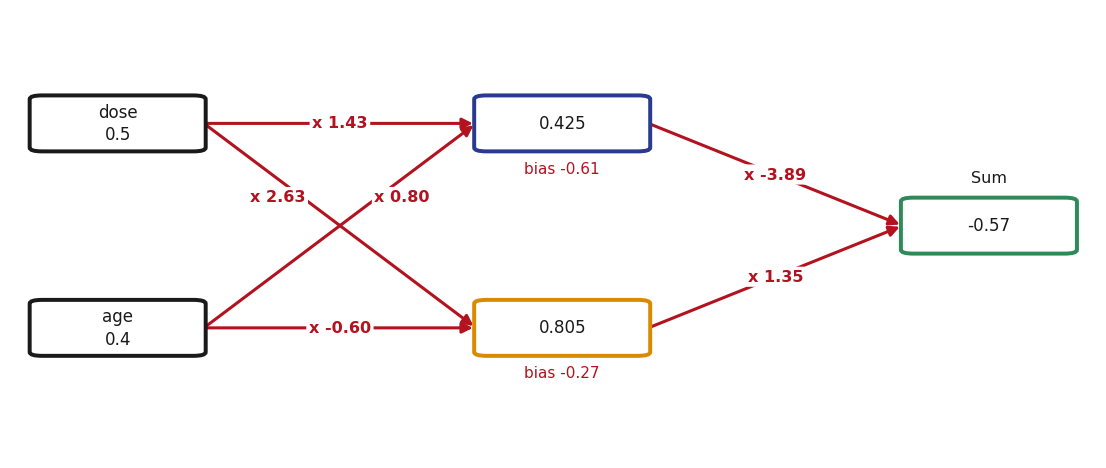

In [25]:
display(two_in(dose=0.5, age=0.4, upto="out"))

### The Same Dose, a Different Person

Run the same dose of 0.5 at age <b style="color:#73000A;">0</b> and the two age terms vanish, which
leaves the network we traced by hand:

$$(0.105 \times -3.89) + (1.045 \times 1.35) = \mathbf{1.00}$$

Effective at age 0, and <b style="color:#73000A;">-0.57</b> at age 0.4. That is what a second input buys:
the answer is allowed to depend on who is asking.

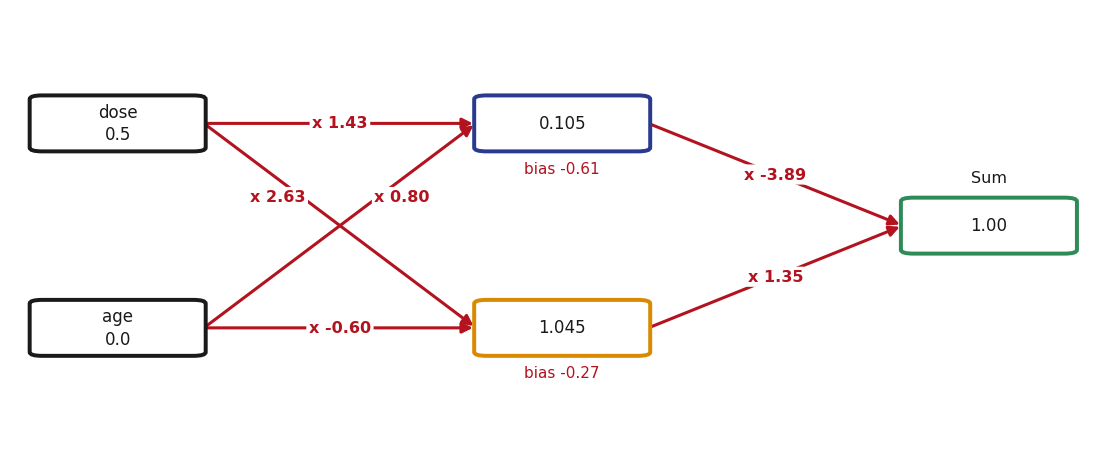

In [26]:
display(two_in(dose=0.5, age=0.0, upto="out"))

### Add an Output

One prediction becomes two. Effectiveness and, say, <b style="color:#73000A;">side effect severity</b>,
from the same two hidden nodes.

Six numbers becomes <b style="color:#73000A;">eight</b>, and the hidden layer is shared.

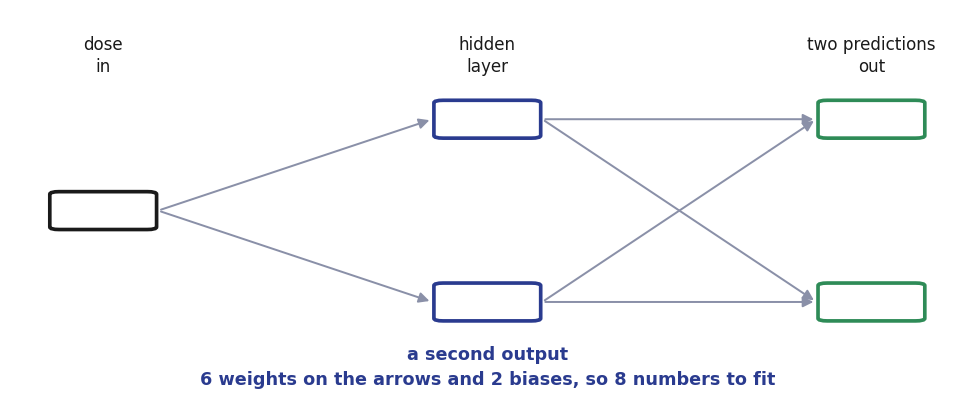

In [27]:
display(draw_net([1, 2, 2],
                 ["dose\nin", "hidden\nlayer", "two predictions\nout"],
                 "a second output"))

### All Three at Once

Two inputs, two hidden layers, two outputs. Still boxes, arrows, and a bend
inside each middle box.

Six numbers becomes <b style="color:#73000A;">sixteen</b>, and this is the smallest network anybody
would call a real one.

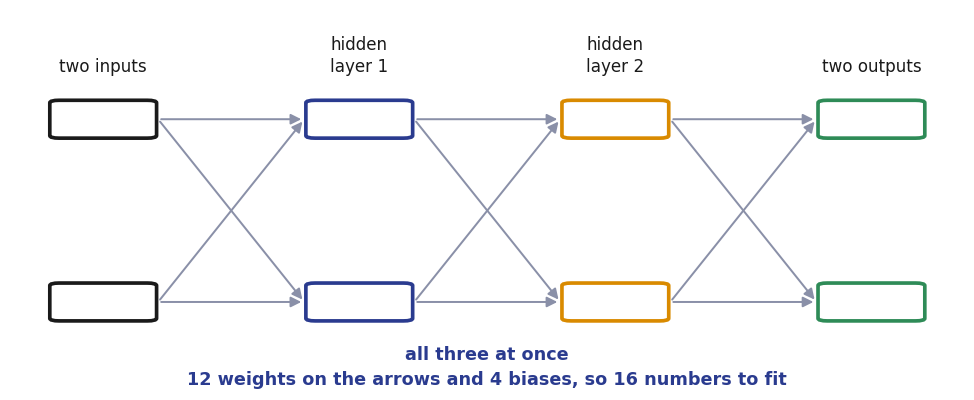

In [28]:
display(draw_net([2, 2, 2, 2],
                 ["two inputs", "hidden\nlayer 1", "hidden\nlayer 2", "two outputs"],
                 "all three at once"))

## Key Ideas

- A neural network is <b style="color:#73000A;">multiply, add, bend</b>, repeated
- <b style="color:#73000A;">Weights</b> multiply, <b style="color:#73000A;">biases</b> add, <b style="color:#73000A;">activation functions</b> bend
- Summing a few bent lines fits shapes no straight line can
- <b style="color:#73000A;">Layers</b>: input, hidden, output. More nodes means more flexibility
- The weights and biases come from <b style="color:#73000A;">backpropagation</b>, which is next
- In PyTorch: subclass `nn.Module`, define `forward()`